----

# 🩺 Project : Churn Analysis — Data Cleaning & Setup
**Dataset:** IBM Telco Customer Churn (7,043 customers, 21 columns)

**What this notebook does:** Loads raw data, fixes data quality issues, 
creates derived business columns, exports to SQLite and clean CSV.

**Key finding:** Overall churn rate is ~26.5%


----

In [2]:
# ===================================================================
# Project Subscription Churn Diagnosis & Customer Health Score
# Step 1: Data Loading, Cleaning, and SQLite Setup
# Author: Abhishek Suwalka
# ===================================================================

import pandas as pd
import numpy as np
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

# Display settings for better readability in notebook
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.width', 200)

print("✅ Libraries loaded successfully")


✅ Libraries loaded successfully


In [3]:
df = pd.read_csv('../data/raw/Telco-Customer-Churn.csv')

## Load the Data

In [4]:
df

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


In [5]:
# First look
print(f"Dataset shape: {df.shape[0]} rows × {df.shape[1]} columns")
print(f"\nColumn names:\n{list(df.columns)}")

Dataset shape: 7043 rows × 21 columns

Column names:
['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


## Initial Data Exploration (EDA = Exploratory Data Analysis)

In [6]:
# ===================================================================
# INITIAL EXPLORATION
# As a BA, you always start by understanding the data BEFORE cleaning.
# Think of this as "interviewing the data" — just like you'd interview
# a stakeholder to understand their process before making recommendations.
# ===================================================================

# 1. Data types and non-null counts
print("=" * 60)
print("DATA TYPES & NULL COUNTS")
print("=" * 60)
df.info()

print("\n")

# 2. Statistical summary for numeric columns
print("=" * 60)
print("NUMERIC SUMMARY")
print("=" * 60)
print(df.describe())

print("\n")

# 3. First 5 rows — see what the data actually looks like
print("=" * 60)
print("FIRST 5 ROWS")
print("=" * 60)
df.head()


DATA TYPES & NULL COUNTS
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling 

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## Understand Categorical Columns

In [7]:
# ===================================================================
# UNDERSTANDING CATEGORICAL VALUES
# Before cleaning, we need to know what values exist in each column.
# This is like a BA reviewing a data dictionary — what are the 
# possible states for each field?
# ===================================================================

# For each non-numeric column, show unique values
for col in df.select_dtypes(include='object').columns:
    unique_vals = df[col].unique()
    print(f"\n{col} ({len(unique_vals)} unique values):")
    print(f"  First Few Values: {unique_vals[:20]}")  # Show first 20
    print(f"  Null count: {df[col].isnull().sum()}")



customerID (7043 unique values):
  First Few Values: ['7590-VHVEG' '5575-GNVDE' '3668-QPYBK' '7795-CFOCW' '9237-HQITU'
 '9305-CDSKC' '1452-KIOVK' '6713-OKOMC' '7892-POOKP' '6388-TABGU'
 '9763-GRSKD' '7469-LKBCI' '8091-TTVAX' '0280-XJGEX' '5129-JLPIS'
 '3655-SNQYZ' '8191-XWSZG' '9959-WOFKT' '4190-MFLUW' '4183-MYFRB']
  Null count: 0

gender (2 unique values):
  First Few Values: ['Female' 'Male']
  Null count: 0

Partner (2 unique values):
  First Few Values: ['Yes' 'No']
  Null count: 0

Dependents (2 unique values):
  First Few Values: ['No' 'Yes']
  Null count: 0

PhoneService (2 unique values):
  First Few Values: ['No' 'Yes']
  Null count: 0

MultipleLines (3 unique values):
  First Few Values: ['No phone service' 'No' 'Yes']
  Null count: 0

InternetService (3 unique values):
  First Few Values: ['DSL' 'Fiber optic' 'No']
  Null count: 0

OnlineSecurity (3 unique values):
  First Few Values: ['No' 'Yes' 'No internet service']
  Null count: 0

OnlineBackup (3 unique values):
  Fir

## Check the Target Variable (Churn)

Churn Distribution:
  No (Retained):  5,174 customers (73.5%)
  Yes (Churned):  1,869 customers (26.5%)

  Overall Churn Rate: 26.5%


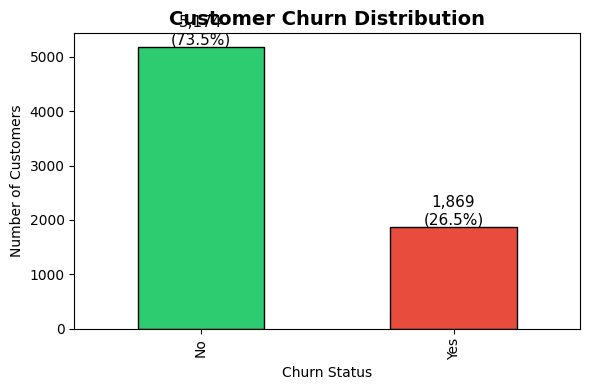

In [8]:
# ===================================================================
# TARGET VARIABLE ANALYSIS
# The very first thing a BA should do: understand the outcome you're
# analyzing. What's the churn rate? Is the data balanced or imbalanced?
# ===================================================================

churn_counts = df['Churn'].value_counts()
churn_pcts = df['Churn'].value_counts(normalize=True) * 100

print("Churn Distribution:")
print(f"  No (Retained):  {churn_counts['No']:,} customers ({churn_pcts['No']:.1f}%)")
print(f"  Yes (Churned):  {churn_counts['Yes']:,} customers ({churn_pcts['Yes']:.1f}%)")
print(f"\n  Overall Churn Rate: {churn_pcts['Yes']:.1f}%")

# Quick visual
fig, ax = plt.subplots(figsize=(6, 4))
colors = ['#2ecc71', '#e74c3c']  # Green for retained, Red for churned
churn_counts.plot(kind='bar', color=colors, ax=ax, edgecolor='black')
ax.set_title('Customer Churn Distribution', fontsize=14, fontweight='bold')
ax.set_xlabel('Churn Status')
ax.set_ylabel('Number of Customers')
for i, (count, pct) in enumerate(zip(churn_counts, churn_pcts)):
    ax.text(i, count + 50, f'{count:,}\n({pct:.1f}%)', ha='center', fontsize=11)
plt.tight_layout()
plt.show()


## Data Cleaning

In [9]:
# ===================================================================
# CLEANING ISSUE #1: TotalCharges is a String, Not a Number
# ===================================================================
# The TotalCharges column is stored as 'object' (string) type.
# This is because some rows have empty strings (' ') instead of 
# numbers. These are customers with 0 months tenure — brand new
# customers who haven't been charged yet.
#
# As a BA, you need to decide: what do we do with these?
# Decision: Convert empty strings to 0 (they've paid nothing yet),
# then convert the column to float.
# ===================================================================

# First, let's see the problem
print(f"TotalCharges dtype BEFORE: {df['TotalCharges'].dtype}")

# Find the problematic rows
empty_charges = df[df['TotalCharges'] == ' ']
print(f"\nRows with empty TotalCharges: {len(empty_charges)}")
print(f"Their tenure values: {empty_charges['tenure'].values}")
# You should see tenure = 0 for all of them — confirms they're new signups

# Fix: replace empty strings with '0', then convert to float
df['TotalCharges'] = df['TotalCharges'].replace(' ', '0')
df['TotalCharges'] = df['TotalCharges'].astype(float)

print(f"\nTotalCharges dtype AFTER: {df['TotalCharges'].dtype}")
print(f"TotalCharges range: ${df['TotalCharges'].min():.2f} — ${df['TotalCharges'].max():.2f}")


TotalCharges dtype BEFORE: object

Rows with empty TotalCharges: 11
Their tenure values: [0 0 0 0 0 0 0 0 0 0 0]

TotalCharges dtype AFTER: float64
TotalCharges range: $0.00 — $8684.80


- tenure = 0 = brand new customers, made a business-informed decision (set to $0)

## Convert SeniorCitizen

In [10]:
# ===================================================================
# CLEANING ISSUE #2: SeniorCitizen is 0/1, Not Yes/No
# ===================================================================
# Every other binary column uses "Yes"/"No" but SeniorCitizen uses 
# 0 and 1. For consistency and readability (especially in dashboards
# and reports), we convert it.
# ===================================================================

df['SeniorCitizen'] = df['SeniorCitizen'].map({0: 'No', 1: 'Yes'})
print(f"SeniorCitizen values after conversion: {df['SeniorCitizen'].unique()}")
print(f"Senior citizens: {(df['SeniorCitizen'] == 'Yes').sum()} ({(df['SeniorCitizen'] == 'Yes').mean()*100:.1f}%)")


SeniorCitizen values after conversion: ['No' 'Yes']
Senior citizens: 1142 (16.2%)


##  Create Derived Columns

In [11]:
# ===================================================================
# FEATURE ENGINEERING: Creating Business-Meaningful Derived Columns
# ===================================================================
# This is where BA thinking shines. We're not just cleaning — we're
# creating NEW columns that make the data more useful for analysis.
# Each derived column answers a business question.
# ===================================================================

# --- 1. Tenure Band ---
# WHY: Analyzing churn by exact month (0-72) is too granular.
# Grouping into bands lets us see lifecycle-stage patterns.
# Think: "Are we losing customers in their first year? Or after 3 years?"

def create_tenure_band(tenure):
    if tenure <= 12:
        return '0-12 months'
    elif tenure <= 24:
        return '13-24 months'
    elif tenure <= 36:
        return '25-36 months'
    elif tenure <= 48:
        return '37-48 months'
    elif tenure <= 60:
        return '49-60 months'
    else:
        return '61-72 months'

df['tenure_band'] = df['tenure'].apply(create_tenure_band)
print("Tenure Band distribution:")
print(df['tenure_band'].value_counts().sort_index())

# --- 2. Monthly Charges Band ---
# WHY: Groups customers by spending level. In SaaS, this maps to
# plan tiers — are we losing budget customers or premium customers?

def create_charges_band(charges):
    if charges < 35:
        return 'Low (<$35)'
    elif charges < 70:
        return 'Medium ($35-$70)'
    else:
        return 'High ($70+)'

df['monthly_charges_band'] = df['MonthlyCharges'].apply(create_charges_band)
print("\nMonthly Charges Band distribution:")
print(df['monthly_charges_band'].value_counts())

# --- 3. Services Count ---
# WHY: How many services/features does the customer use? 
# More services = more "sticky" = less likely to churn (usually).
# This is like "feature adoption depth" in SaaS.

service_columns = ['PhoneService', 'MultipleLines', 'InternetService',
                   'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
                   'TechSupport', 'StreamingTV', 'StreamingMovies']

# Count services where the value is 'Yes' (not 'No' or 'No internet service')
df['services_count'] = df[service_columns].apply(
    lambda row: sum(1 for val in row if val == 'Yes'), axis=1
)
print(f"\nServices Count range: {df['services_count'].min()} to {df['services_count'].max()}")
print("Distribution:")
print(df['services_count'].value_counts().sort_index())

# --- 4. Has Security ---
# WHY: TechSupport and OnlineSecurity are "protection" services.
# Customers who DON'T have these are often more frustrated (unresolved 
# issues) and more likely to churn. This flag helps us test that.

df['has_security'] = ((df['TechSupport'] == 'Yes') | 
                       (df['OnlineSecurity'] == 'Yes')).map({True: 'Yes', False: 'No'})
print(f"\nHas Security distribution:")
print(df['has_security'].value_counts())

# --- 5. Churn Binary (for calculations) ---
# WHY: Having a 0/1 numeric version of Churn makes math easy.
# e.g., avg of this column = churn rate. Very handy for groupby.

df['churn_binary'] = (df['Churn'] == 'Yes').astype(int)

print(f"\n✅ All derived columns created. New shape: {df.shape}")


Tenure Band distribution:
tenure_band
0-12 months     2186
13-24 months    1024
25-36 months     832
37-48 months     762
49-60 months     832
61-72 months    1407
Name: count, dtype: int64

Monthly Charges Band distribution:
monthly_charges_band
High ($70+)         3591
Low (<$35)          1731
Medium ($35-$70)    1721
Name: count, dtype: int64

Services Count range: 0 to 8
Distribution:
services_count
0      80
1    1701
2    1188
3     965
4     922
5     908
6     676
7     395
8     208
Name: count, dtype: int64

Has Security distribution:
has_security
No     4079
Yes    2964
Name: count, dtype: int64

✅ All derived columns created. New shape: (7043, 26)


##  Final Validation

In [12]:
# ===================================================================
# VALIDATION: Make Sure Everything Is Clean
# ===================================================================
# Before we load into SQLite, verify there are no remaining issues.
# A good BA always validates before handing off data.
# ===================================================================

print("=" * 60)
print("FINAL VALIDATION")
print("=" * 60)

# 1. Check for remaining nulls
null_counts = df.isnull().sum()
if null_counts.sum() == 0:
    print("✅ No null values in any column")
else:
    print("⚠️ Null values found:")
    print(null_counts[null_counts > 0])

# 2. Check data types
print(f"\n📊 Final column count: {df.shape[1]}")
print(f"📊 Final row count: {df.shape[0]}")

print("\nData types:")
for col in df.columns:
    print(f"  {col:30s} → {df[col].dtype}")

# 3. Quick sanity checks
print(f"\n🔍 Sanity Checks:")
print(f"  Churn rate: {df['churn_binary'].mean()*100:.1f}%")
print(f"  Avg tenure: {df['tenure'].mean():.1f} months")
print(f"  Avg monthly charges: ${df['MonthlyCharges'].mean():.2f}")
print(f"  Avg total charges: ${df['TotalCharges'].mean():.2f}")
print(f"  Unique customer IDs: {df['customerID'].nunique()}")


FINAL VALIDATION
✅ No null values in any column

📊 Final column count: 26
📊 Final row count: 7043

Data types:
  customerID                     → object
  gender                         → object
  SeniorCitizen                  → object
  Partner                        → object
  Dependents                     → object
  tenure                         → int64
  PhoneService                   → object
  MultipleLines                  → object
  InternetService                → object
  OnlineSecurity                 → object
  OnlineBackup                   → object
  DeviceProtection               → object
  TechSupport                    → object
  StreamingTV                    → object
  StreamingMovies                → object
  Contract                       → object
  PaperlessBilling               → object
  PaymentMethod                  → object
  MonthlyCharges                 → float64
  TotalCharges                   → float64
  Churn                          → object
  tenu

## Load into SQLite

In [13]:
# ===================================================================
# LOAD CLEANED DATA INTO SQLITE DATABASE
# ===================================================================
# WHY SQLite? 
# 1. It's built into Python — zero installation needed
# 2. You can write real SQL queries (same syntax as PostgreSQL/MySQL
#    for 95% of BA use cases)
# 3. The .db file is portable — you can share it, open it on Windows
#    for Power BI, etc.
# 4. It proves you know SQL in a real environment, not just practice 
#    sites like HackerRank
# ===================================================================

# Create the database (this creates a file on disk)
# Update path for your setup:
db_path = '../data/cleaned/telco_churn.db'  # For local Jupyter
# db_path = 'telco_churn.db'  # For Colab

conn = sqlite3.connect(db_path)

# Write the DataFrame to a SQL table
df.to_sql('customers', conn, if_exists='replace', index=False)

# Verify it worked
cursor = conn.cursor()
cursor.execute("SELECT COUNT(*) FROM customers")
row_count = cursor.fetchone()[0]
print(f"✅ SQLite database created: {db_path}")
print(f"✅ Table 'customers' contains {row_count:,} rows")

# Quick test query to make sure SQL works
cursor.execute("""
    SELECT Churn, COUNT(*) as count, 
           ROUND(AVG(MonthlyCharges), 2) as avg_monthly
    FROM customers 
    GROUP BY Churn
""")
print("\n🧪 Test Query — Churn vs Avg Monthly Charges:")
for row in cursor.fetchall():
    print(f"  Churn={row[0]}: {row[1]:,} customers, Avg Monthly=${row[2]}")

conn.close()
print("\n✅ Database connection closed.")


✅ SQLite database created: ../data/cleaned/telco_churn.db
✅ Table 'customers' contains 7,043 rows

🧪 Test Query — Churn vs Avg Monthly Charges:
  Churn=No: 5,174 customers, Avg Monthly=$61.27
  Churn=Yes: 1,869 customers, Avg Monthly=$74.44

✅ Database connection closed.


## Save Cleaned CSV (Backup & for Power BI Later)

In [14]:
# ===================================================================
# EXPORT CLEANED CSV
# ===================================================================
# We save a clean CSV separately because:
# 1. Power BI reads CSV/Excel better than SQLite
# 2. It's good to have a non-database backup
# 3. You might want to share just the CSV with someone
# ===================================================================

csv_path = '../data/cleaned/telco_churn_cleaned.csv'  # Local Jupyter
# csv_path = 'telco_churn_cleaned.csv'  # Colab

df.to_csv(csv_path, index=False)
print(f"✅ Cleaned CSV saved: {csv_path}")
print(f"   {df.shape[0]} rows × {df.shape[1]} columns")


✅ Cleaned CSV saved: ../data/cleaned/telco_churn_cleaned.csv
   7043 rows × 26 columns
